# Demo & audit augmentation cho VisDrone

Notebook này **không ghi đè EDA** và **không sinh dataset augmented cố định**. Mục tiêu:

1. kiểm tra trực quan augmentation dùng chung cho Faster R-CNN, YOLO và RT-DETR;
2. xác nhận bounding box luôn đi cùng ảnh, nằm trong biên và đồng bộ label;
3. đo số box bị loại trên 100 ảnh train;
4. minh họa bbox copy-paste cho lớp hiếm và chỉ ra vì sao chưa nên bật mặc định.

Augmentation chỉ áp dụng online trên `train`; `val/test` giữ nguyên. Kế hoạch chi tiết nằm ở `docs/augmentation_plan.md`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd
from PIL import Image

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from augmentation import (
    AugmentationConfig,
    ControlledDetectionAugmenter,
    paste_bbox_patch,
)
from visdrone_data import (
    CLASS_NAMES,
    evaluate_annotation,
    read_annotation_file,
    resolve_split_dir,
)

DATA_ROOT = PROJECT_ROOT / "data"
TRAIN_DIR = resolve_split_dir(DATA_ROOT, "train")
CLASS_NAMES_ZERO = {category - 1: name for category, name in CLASS_NAMES.items()}
print("Train:", TRAIN_DIR)
print("Policy:", AugmentationConfig())

Train: /Users/ai/Documents/HCMUS/Nam3/Ki3/Hoc TK/Object_dectection/data/VisDrone2019-DET-train/VisDrone2019-DET-train
Policy: AugmentationConfig(horizontal_flip_probability=0.5, vertical_flip_probability=0.2, affine_probability=0.6, max_rotation_degrees=10.0, max_translate_fraction=0.05, scale_min=0.9, scale_max=1.1, photometric_probability=0.8, brightness_min=0.85, brightness_max=1.15, contrast_min=0.85, contrast_max=1.15, blur_probability=0.1, blur_radius_max=1.0, min_box_size=2.0, min_visibility=0.3, fill_color=(114, 114, 114))


## 1. Đọc sample và chọn ca khó

Ba ảnh được chọn tự động từ train:

- `crowded`: nhiều trainable boxes nhất;
- `rare`: có lớp awning-tricycle;
- `tiny`: có box với cạnh ngắn nhỏ nhất.

Việc chọn tự động giúp notebook tái lập được sau khi clone data ở máy khác.

In [2]:
def load_sample(stem):
    image_path = next((TRAIN_DIR / "images").glob(f"{stem}.*"))
    image = Image.open(image_path).convert("RGB")
    rows, malformed = read_annotation_file(TRAIN_DIR / "annotations" / f"{stem}.txt")
    boxes, labels = [], []
    for row in rows:
        status, xywh, _ = evaluate_annotation(row, image.width, image.height)
        if status != "keep":
            continue
        x, y, width, height = xywh
        boxes.append([x, y, x + width, y + height])
        labels.append(row.category - 1)
    return image, np.asarray(boxes, dtype=np.float32).reshape(-1, 4), np.asarray(labels, dtype=np.int64)


def draw_detection(ax, image, boxes, labels, title, max_boxes=250):
    ax.imshow(image)
    for box, label in zip(boxes[:max_boxes], labels[:max_boxes]):
        x1, y1, x2, y2 = box
        color = plt.cm.tab10(int(label) % 10)
        ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1,
                               fill=False, edgecolor=color, linewidth=0.8))
    suffix = "" if len(boxes) <= max_boxes else f" (vẽ {max_boxes}/{len(boxes)})"
    ax.set_title(f"{title}\n{len(boxes)} boxes{suffix}")
    ax.axis("off")


records = []
for annotation_path in sorted((TRAIN_DIR / "annotations").glob("*.txt")):
    rows, _ = read_annotation_file(annotation_path)
    trainable = [row for row in rows if row.score > 0 and row.category in CLASS_NAMES]
    if not trainable:
        continue
    records.append({
        "stem": annotation_path.stem,
        "count": len(trainable),
        "has_rare": any(row.category == 8 for row in trainable),
        "min_side": min(min(row.width, row.height) for row in trainable if row.width > 0 and row.height > 0),
    })

record_df = pd.DataFrame(records)
selected = {
    "crowded": record_df.loc[record_df["count"].idxmax(), "stem"],
    "rare": record_df.loc[record_df["has_rare"], "stem"].iloc[0],
    "tiny": record_df.loc[record_df["min_side"].idxmin(), "stem"],
}
pd.DataFrame([{"case": case, "stem": stem} for case, stem in selected.items()])

,case,stem
0,crowded,0000059_01886_d_0000114
1,rare,0000002_00005_d_0000014
2,tiny,0000182_01653_d_0000040


## 2. So sánh ảnh gốc với ba biến thể

Mỗi biến thể dùng seed cố định khác nhau. Mục cần nhìn kỹ: box có còn bám object, box sát biên có hợp lệ, object rất nhỏ có bị blur/xoay làm mất tín hiệu hay không. Đây là lý do policy chỉ dùng affine và blur nhẹ.

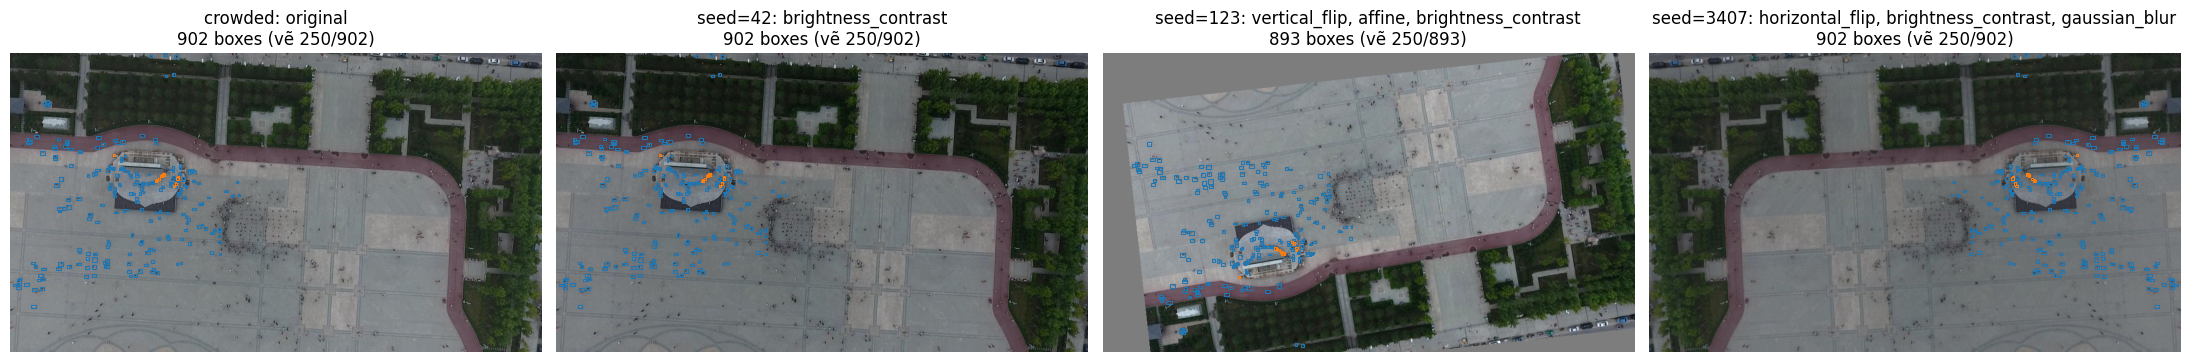

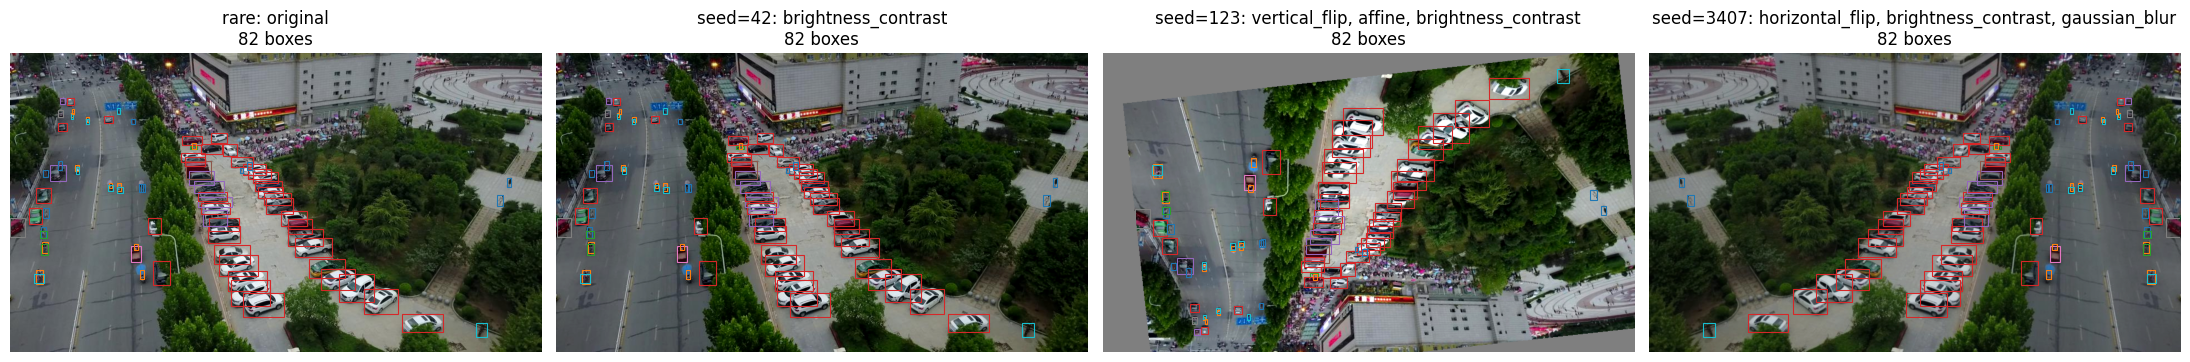

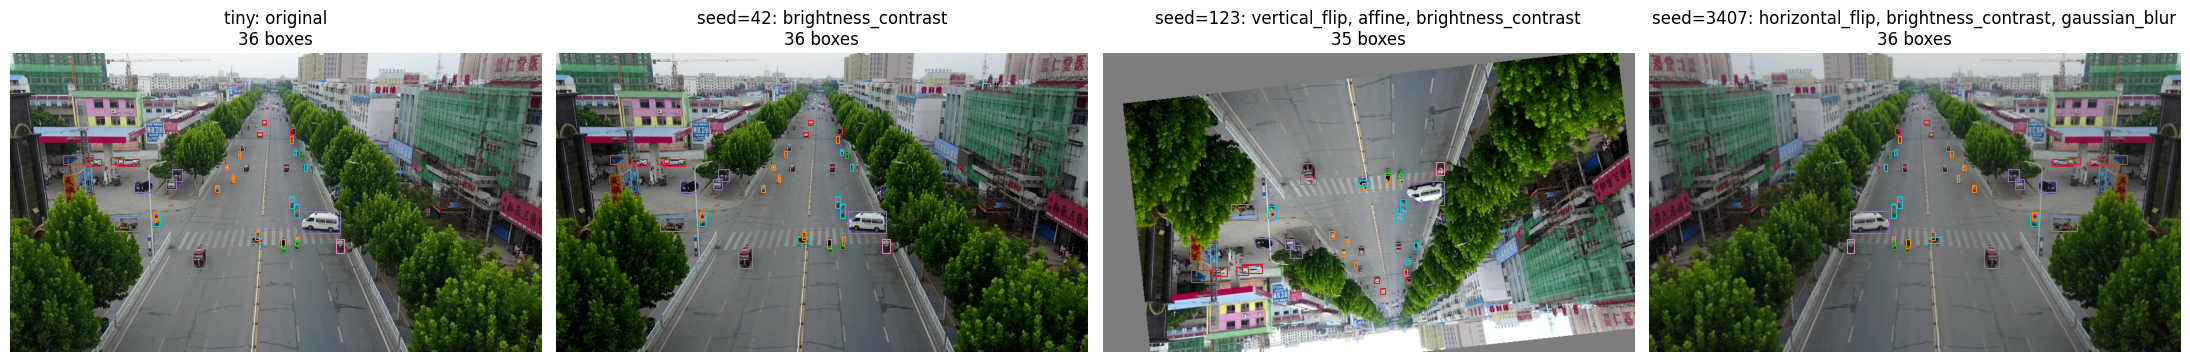

In [3]:
for case, stem in selected.items():
    image, boxes, labels = load_sample(stem)
    fig, axes = plt.subplots(1, 4, figsize=(22, 6))
    draw_detection(axes[0], image, boxes, labels, f"{case}: original")
    for column, seed in enumerate([42, 123, 3407], start=1):
        augmented, aug_boxes, aug_labels, audit = ControlledDetectionAugmenter(seed=seed)(
            image, boxes, labels
        )
        draw_detection(
            axes[column], augmented, aug_boxes, aug_labels,
            f"seed={seed}: {', '.join(audit['applied']) or 'none'}"
        )
    plt.tight_layout()
    plt.show()

### Kết luận phần trực quan

- Flip/affine thay đổi đồng thời ảnh và box; không có hiện tượng ảnh đổi nhưng box giữ nguyên.
- Affine được giới hạn để không thu nhỏ object quá mạnh. Box sau biến đổi được clip theo ảnh và object còn dưới 30% diện tích sẽ bị loại.
- Blur chỉ có xác suất 10% và radius tối đa 1 vì VisDrone có rất nhiều object chỉ vài pixel.
- Nếu ảnh thực tế triển khai luôn có một hướng cố định, cần ablation `vertical_flip=0`; ảnh drone có thể đổi yaw nên horizontal flip và rotation nhẹ vẫn hợp lý.

## 3. Audit 100 ảnh train

Audit kiểm tra: số box trước/sau, invalid box, label có đồng bộ, tỷ lệ giữ box và phép biến đổi đã dùng. Lấy mẫu cách đều để không chỉ xem một sequence liên tiếp.

In [4]:
audit_indices = np.linspace(0, len(record_df) - 1, 100, dtype=int)
audit_rows = []
for audit_number, index in enumerate(audit_indices):
    stem = record_df.iloc[index]["stem"]
    image, boxes, labels = load_sample(stem)
    augmented, aug_boxes, aug_labels, metadata = ControlledDetectionAugmenter(
        seed=10_000 + audit_number
    )(image, boxes, labels)
    invalid = int(
        (~np.isfinite(aug_boxes).all(axis=1)
         | (aug_boxes[:, 0] < 0) | (aug_boxes[:, 1] < 0)
         | (aug_boxes[:, 2] > image.width) | (aug_boxes[:, 3] > image.height)
         | (aug_boxes[:, 2] <= aug_boxes[:, 0])
         | (aug_boxes[:, 3] <= aug_boxes[:, 1])).sum()
    ) if len(aug_boxes) else 0
    audit_rows.append({
        "stem": stem,
        "boxes_before": len(boxes),
        "boxes_after": len(aug_boxes),
        "dropped": len(boxes) - len(aug_boxes),
        "invalid_boxes": invalid,
        "labels_synced": len(aug_boxes) == len(aug_labels),
        "applied": ", ".join(metadata["applied"]),
    })

audit_df = pd.DataFrame(audit_rows)
audit_summary = pd.DataFrame({
    "metric": [
        "images audited", "boxes before", "boxes after", "retention (%)",
        "invalid boxes", "label mismatch images", "images with dropped boxes",
    ],
    "value": [
        len(audit_df), audit_df.boxes_before.sum(), audit_df.boxes_after.sum(),
        100 * audit_df.boxes_after.sum() / audit_df.boxes_before.sum(),
        audit_df.invalid_boxes.sum(), (~audit_df.labels_synced).sum(),
        (audit_df.dropped > 0).sum(),
    ],
})
audit_summary

,metric,value
0,images audited,100.00000
1,boxes before,5833.00000
2,boxes after,5747.00000
3,retention (%),98.52563
4,invalid boxes,0.00000
5,label mismatch images,0.00000
6,images with dropped boxes,20.00000


In [5]:
assert audit_df.invalid_boxes.sum() == 0
assert audit_df.labels_synced.all()
assert (audit_df.boxes_after <= audit_df.boxes_before).all()
audit_df.sort_values("dropped", ascending=False).head(10)

,stem,boxes_before,boxes_after,dropped,invalid_boxes,labels_synced,applied
18,0000344_01569_d_0000301,79,40,39,0,True,"horizontal_flip, affine, brightness_contrast, ..."
1,0000068_04169_d_0000014,189,175,14,0,True,affine
84,9999991_00000_d_0000014,125,117,8,0,True,"horizontal_flip, affine"
64,9999969_00000_d_0000010,63,60,3,0,True,"affine, brightness_contrast"
72,9999981_00000_d_0000062,56,54,2,0,True,"horizontal_flip, affine, brightness_contrast, ..."
57,9999962_00000_d_0000089,52,50,2,0,True,"horizontal_flip, affine, brightness_contrast"
92,9999998_00387_d_0000339,26,24,2,0,True,"horizontal_flip, affine, brightness_contrast"
48,9999955_00000_d_0000237,85,83,2,0,True,"vertical_flip, affine, brightness_contrast"
76,9999982_00000_d_0000166,54,52,2,0,True,"affine, brightness_contrast"
88,9999998_00076_d_0000061,126,124,2,0,True,affine


### Kết luận audit

Các assertion phía trên là điều kiện bắt buộc: `invalid_boxes = 0`, số label luôn bằng số box và augmentation không tự sinh box. Một ít box sát biên có thể bị loại do không còn đủ visibility; nếu tỷ lệ giữ box thấp hơn khoảng 97–98%, cần giảm rotation/translation hoặc min-visibility trước khi train thật.

Audit này kiểm tra tính toàn vẹn hình học, chưa chứng minh augmentation làm tăng accuracy. Hiệu quả phải được xác nhận bằng A0 (không aug) so với A1 (controlled aug) trên validation metrics.

## 4. Demo bbox copy-paste lớp hiếm (experimental)

Ultralytics `copy_paste` chính thức chỉ hỗ trợ segmentation. VisDrone chỉ có bounding box nên demo dưới đây sao chép cả patch chữ nhật, bao gồm nền quanh object. Hàm từ chối paste nếu IoA với object có sẵn vượt 0.10. Hãy quan sát đường nối và ngữ cảnh trước khi quyết định dùng.

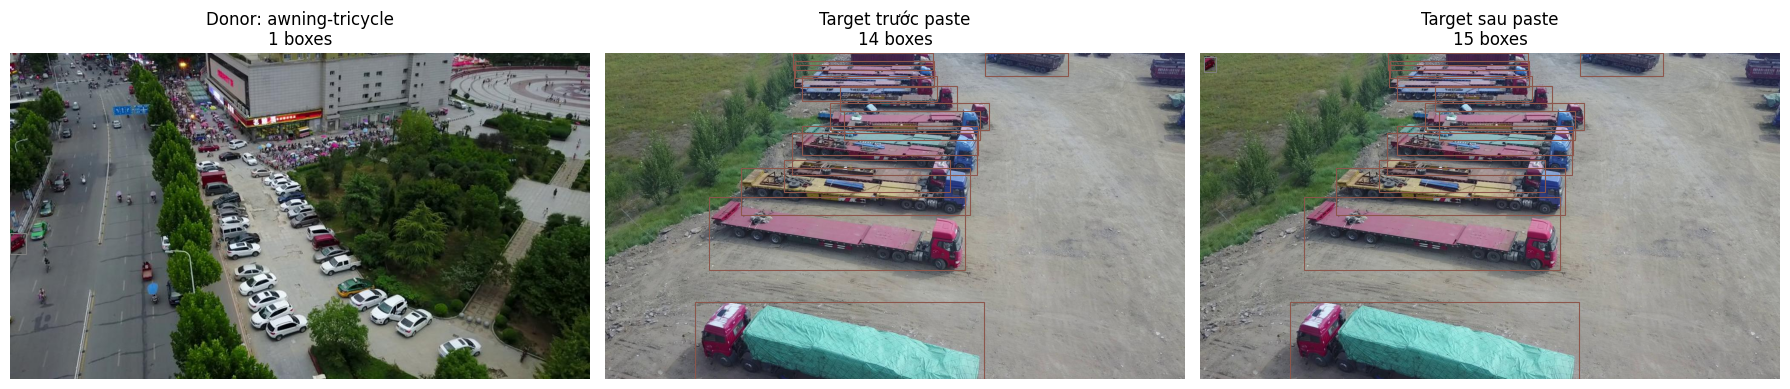

{'operation': 'experimental_bbox_copy_paste',
 'destination_box': [10.0, 10.0, 36.0, 44.0],
 'donor_box': [0.0, 298.0, 26.0, 332.0],
 'maximum_intersection_over_area': 0.0,
 'warning': 'rectangular context copied because instance masks are unavailable'}

In [6]:
donor_stem = selected["rare"]
donor_image, donor_boxes, donor_labels = load_sample(donor_stem)
donor_index = int(np.flatnonzero(donor_labels == 7)[0])  # awning-tricycle

target_candidates = record_df[(record_df["count"] >= 1) & (record_df["count"] <= 15)]
copy_result = None
for target_stem in target_candidates["stem"].head(200):
    target_image, target_boxes, target_labels = load_sample(target_stem)
    patch_width = int(round(donor_boxes[donor_index, 2] - donor_boxes[donor_index, 0]))
    patch_height = int(round(donor_boxes[donor_index, 3] - donor_boxes[donor_index, 1]))
    for y in range(10, max(11, target_image.height - patch_height), max(20, patch_height)):
        for x in range(10, max(11, target_image.width - patch_width), max(20, patch_width)):
            try:
                copy_result = paste_bbox_patch(
                    target_image, target_boxes, target_labels,
                    donor_image, donor_boxes[donor_index], int(donor_labels[donor_index]),
                    destination_xy=(x, y), max_intersection_over_area=0.10,
                )
                break
            except ValueError:
                continue
        if copy_result is not None:
            break
    if copy_result is not None:
        break

assert copy_result is not None, "Không tìm được vị trí paste an toàn"
pasted_image, pasted_boxes, pasted_labels, paste_audit = copy_result

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
draw_detection(axes[0], donor_image, donor_boxes[[donor_index]], donor_labels[[donor_index]],
               "Donor: awning-tricycle")
draw_detection(axes[1], target_image, target_boxes, target_labels, "Target trước paste")
draw_detection(axes[2], pasted_image, pasted_boxes, pasted_labels, "Target sau paste")
plt.tight_layout()
plt.show()
paste_audit

### Kết luận copy-paste

Demo chứng minh có thể cập nhật box/label đúng, nhưng **không chứng minh patch hợp ngữ cảnh**. Do không có instance mask, patch có nền chữ nhật và có thể đặt xe lên mái nhà/vỉa hè. Vì vậy:

- không bật trong baseline A1;
- chỉ nhắm lớp hiếm sau khi xác nhận phân bố class;
- kiểm duyệt ít nhất 200 ảnh sinh ra;
- tối đa 1–3 patch/ảnh, giữ kích thước thật và placement trên vùng đường;
- chỉ giữ recipe nếu `AP_small` và AP lớp hiếm tăng trên validation mà không làm giảm AP tổng.

Nếu copy-paste được ưu tiên, nên bổ sung instance mask/road mask hoặc dùng phương pháp context-aware thay vì rectangle paste thuần.

## 5. Plan chạy cho ba model

| Vòng | Faster R-CNN | YOLO | RT-DETR |
|---|---|---|---|
| A0 | resize/normalize, không aug | toàn bộ aug = 0 | processor, không aug |
| A1 | Torchvision v2 tương đương policy chung | flip/affine/HSV nhẹ, Mosaic=0 | augment trước image processor |
| A2 | input/anchor nhỏ ablation | Mosaic 0.25 và 0.5, close 10 epoch | input 800 vs 1280 |
| A3 | rare bbox copy-paste nếu audit đạt | custom bbox copy-paste ngoài native trainer nếu thật sự cần | rare bbox copy-paste nếu audit đạt |
| A4 | tiling 640 overlap 20% | tiling 640 overlap 20% | tiling 640 overlap 20% |

Theo dõi `mAP50-95`, `AP_small`, AP/AR từng class, recall theo mật độ, VRAM, thời gian train và inference. Top-2 recipe nên chạy ba seed. Demo/audit chạy local; training 1280/tiling/RT-DETR nên chạy GPU Kaggle.